# DW Template Notebook (Step-by-Step)

## a complete teaching module:
```
	•	messy data → clean data ✔️
	•	medallion architecture ✔️
	•	star schema ✔️
	•	OLAP queries ✔️
	•	business storytelling ✔️
```

---

# 🟫⚪🟡 Medallion Architecture Summary Cell


# 🏗️ Medallion Architecture Summary

```
This notebook follows the **Medallion Architecture**, 
which organizes data into three layers:

---
## 🟫 Bronze Layer (Raw Data)

**Purpose:**
- Store raw data exactly as received
- No cleaning or transformation

**Tables:**
- `bronze_books`
- `bronze_sales`

**Characteristics:**
- messy data (NULLs, duplicates, inconsistent formats)
- source of truth for auditing

---
## ⚪ Silver Layer (Cleaned Data)

**Purpose:**
- Clean, standardize, and validate data

**Tables:**
- `silver_books`
- `silver_sales_clean`

**Transformations Applied:**
- removed duplicates
- handled NULL values
- standardized date formats
- enforced transaction integrity

---
## 🟡 Gold Layer (Business-Ready Data)

**Purpose:**
- Create a **Star Schema** for analytics

**Tables:**
- `dim_book`
- `dim_location`
- `dim_date`
- `fact_sales`

**Characteristics:**
- optimized for BI queries
- fast joins
- structured for OLAP

---
## 📊 BI Layer (Analytics)

Using the Gold layer, we performed:

- revenue analysis
- ranking (Top-N)
- time-series trends
- geographic analysis
- segmentation
- multi-dimensional OLAP

---
## 🧠 Key Takeaway

```text

Raw Data → Clean Data → Star Schema → Business Insights

⸻

🚀 Why Medallion Architecture?
	•	improves data quality
	•	enables scalability
	•	separates concerns
	•	supports reliable analytics

⸻

This architecture is widely used in modern data platforms:
	•	Databricks
	•	Snowflake
	•	BigQuery
```

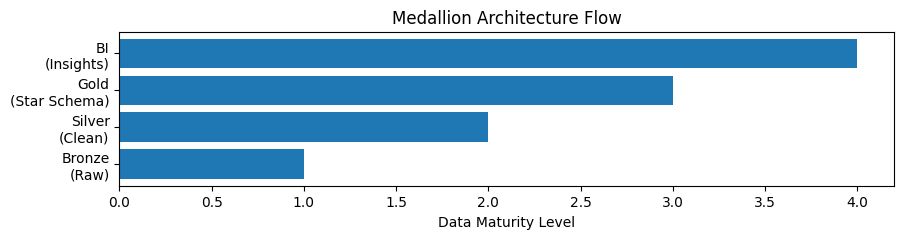

In [1]:
## 📊 **Optional Code Cell (Visual Diagram)**

import matplotlib.pyplot as plt

layers = ["Bronze\n(Raw)", "Silver\n(Clean)", "Gold\n(Star Schema)", "BI\n(Insights)"]
levels = [1, 2, 3, 4]

plt.figure(figsize=(10,2))
plt.barh(layers, levels)

plt.title("Medallion Architecture Flow")
plt.xlabel("Data Maturity Level")

plt.show()

---
# 💡 Teaching Tip (Very Powerful)

```
After this cell, ask:

“Which layer should BI queries run on?”

👉 Expected answer:

Gold layer

Then ask:

“Why not Bronze or Silver?”

👉 This reinforces:
	•	separation of concerns
	•	performance
	•	data quality

⸻

🎯 What this cell achieves
	•	connects all previous work
	•	gives big picture clarity
	•	prepares students for real-world systems

⸻

```

# 🟫 CELL 1 — Load Raw Data (Bronze Layer Entry Point)

```
✅ 1. What are we doing?

We are:
	•	Loading raw CSV files (books.csv, sales.csv)
	•	This is the Bronze layer ingestion
	•	No cleaning, no transformation — just bring data into the system

👉 This mimics real-world ingestion from:
	•	files
	•	APIs
	•	OLTP systems

⸻

💼 2. Business Value
	•	Establishes a single source of truth
	•	Enables data lineage (we know where data came from)
	•	Critical for:
	•	auditing
	•	debugging
	•	reproducibility

👉 Without this step, everything downstream is unreliable

```

In [2]:
#🧾 3. SQL + Python

# 1. Import the Required Library
import duckdb

# 2. Create a DuckDB Connection Object
con = duckdb.connect()

# 3. Define file paths (outside SQL)
books_path = "data/books.csv"
sales_path = "data/sales.csv"

# 4. Create Bronze table: `bronze_books`
con.execute(f"""
CREATE OR REPLACE TABLE bronze_books AS
SELECT * FROM read_csv_auto('{books_path}')
""")

# 5. Create Bronze table: `bronze_sales`
con.execute(f"""
CREATE OR REPLACE TABLE bronze_sales AS
SELECT * FROM read_csv_auto('{sales_path}')
""")

# 5. Validate load
con.execute("""
SELECT 'bronze_books' AS table_name, COUNT(*) AS row_count FROM bronze_books
UNION ALL
SELECT 'bronze_sales', COUNT(*) FROM bronze_sales
""").df()

,table_name,row_count
0,bronze_books,120
1,bronze_sales,21000


In [3]:
# 📊 4. Nice Plot (Row Count Overview)

import matplotlib.pyplot as plt

df_counts = con.execute("""
SELECT 'bronze_books' AS table_name, COUNT(*) AS row_count FROM bronze_books
UNION ALL
SELECT 'bronze_sales', COUNT(*) FROM bronze_sales
""").df()

df_counts

,table_name,row_count
0,bronze_books,120
1,bronze_sales,21000


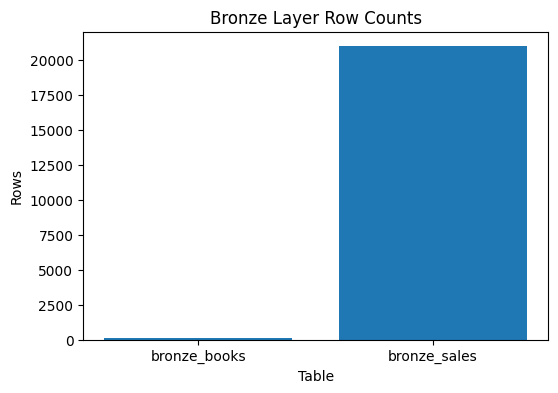

In [4]:
# Plot the Counts of Bronze Tables
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(df_counts["table_name"], df_counts["row_count"])
plt.title("Bronze Layer Row Counts")
plt.xlabel("Table")
plt.ylabel("Rows")
plt.show()

## 📈 5. Business Analysis
	•	We confirm:
	•	books ≈ 120 rows
	•	sales ≈ 21,000 rows

👉 Immediate insight:
	•	Sales is a fact-heavy table
	•	Books is a dimension-like table

This sets up:
	•	fact vs dimension thinking
	•	scaling considerations

⸻

👉 Next Step: move to:

🟫 CELL 2 — Detect Data Quality Issues (MOST IMPORTANT STEP)

This is where the real teaching begins 🔥

---
# 🟫 CELL 2 — Detect Data Quality Issues (MOST IMPORTANT STEP)
Explain the step.

```
This is where the real data engineering thinking starts.

⸻

🟫 CELL 2 — Detect Data Quality Issues (Bronze Profiling)

⸻

✅ 1. What are we doing?

We are:
	•	profiling raw data
	•	identifying:
	•	duplicates
	•	NULL values
	•	inconsistent formats (dates)

👉 This is NOT cleaning yet
👉 This is understanding the mess

Think of this as:

“What’s wrong with my data before I touch it?”

⸻

💼 2. Business Value
	•	Prevents wrong analytics
	•	Avoids bad decisions
	•	Builds trust in data

Real-world impact:
	•	Duplicate sales → inflated revenue
	•	NULL transaction_id → untraceable transactions
	•	inconsistent dates → broken time analysis

👉 If you skip this step → your BI is garbage

```

In [5]:
#🧾 3. SQL (Data Quality Checks)

# ----------------------------------------
# 1. Duplicate Books
# ----------------------------------------
dup_books = con.execute("""
SELECT COUNT(*) AS duplicate_books
FROM (
    SELECT book_id, book_title, book_genre,
           author_id, author_name,
           author_gender, author_web_site,
           published_date, publisher,
           COUNT(*) AS cnt
    FROM bronze_books
    GROUP BY ALL
    HAVING COUNT(*) > 1
)
""").df()

dup_books

,duplicate_books
0,20


In [6]:
# --------------------------------------------------
# 2. NULL transaction_id (CRITICAL)
#
# If a sales transaction has a transaction_id of NULL
# Then we will drop that record (business rule)
# --------------------------------------------------
null_tx = con.execute("""
SELECT COUNT(*) AS null_transaction_id
FROM bronze_sales
WHERE transaction_id IS NULL
""").df()

null_tx

,null_transaction_id
0,100


In [7]:
# ----------------------------------------
# 3. NULL book_format
# ----------------------------------------
null_format = con.execute("""
SELECT COUNT(*) AS null_book_format
FROM bronze_sales
WHERE book_format IS NULL
""").df()

null_format

,null_book_format
0,200


In [8]:
# ----------------------------------------
# 4. NULL discount
# ----------------------------------------
null_discount = con.execute("""
SELECT COUNT(*) AS null_discount
FROM bronze_sales
WHERE discount IS NULL
""").df()

null_discount

,null_discount
0,300


In [9]:
# ----------------------------------------
# 5. Mixed Date Formats
# ----------------------------------------
mixed_dates = con.execute("""
SELECT COUNT(*) AS non_standard_dates
FROM bronze_sales
WHERE date_sold LIKE '%/%'
""").df()

mixed_dates

,non_standard_dates
0,14046


In [10]:
dup_books, null_tx, null_format, null_discount, mixed_dates

(   duplicate_books
 0               20,
    null_transaction_id
 0                  100,
    null_book_format
 0               200,
    null_discount
 0            300,
    non_standard_dates
 0               14046)

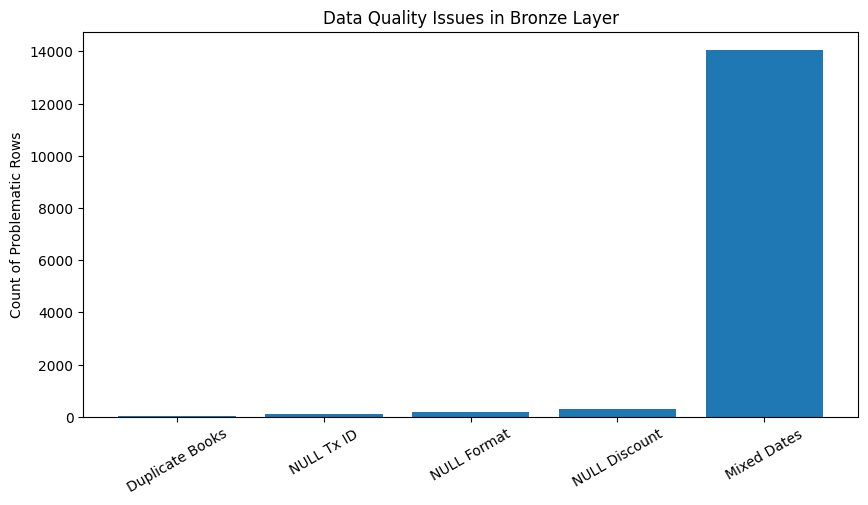

In [11]:
## 📊 4. Nice Plot (Data Quality Dashboard)

import matplotlib.pyplot as plt

issues = [
    ("Duplicate Books", dup_books.iloc[0,0]),
    ("NULL Tx ID", null_tx.iloc[0,0]),
    ("NULL Format", null_format.iloc[0,0]),
    ("NULL Discount", null_discount.iloc[0,0]),
    ("Mixed Dates", mixed_dates.iloc[0,0]),
]

labels = [i[0] for i in issues]
values = [i[1] for i in issues]

plt.figure(figsize=(10,5))
plt.bar(labels, values)
plt.title("Data Quality Issues in Bronze Layer")
plt.ylabel("Count of Problematic Rows")
plt.xticks(rotation=30)
plt.show()

---
# 📈 5. Business Analysis

### 🔴 Key Findings
```
	•	Duplicate books exist → dimension corruption risk
	•	NULL transaction_id → must DROP (non-recoverable)
	•	NULL discount → safe to default to 0
	•	NULL book_format → safe to default to ‘hard_copy’
	•	Mixed date formats → must standardize
```
⸻

### 🧠 Critical Insight

Not all bad data is equal:

|Issue	             | Action
|--------------------|-----------|
|NULL transaction_id |	❌ DROP  |
|duplicate rows	     | ❌ REMOVE |
|NULL discount	     | ✅ IMPUTE |
|NULL format	     | ✅ IMPUTE |
|bad date format	 |🔧 FIX     |

👉 This distinction is core to data engineering

⸻

### 💡 Teaching Moment

Ask students:

“Should we fix or drop bad data?”

```
👉 This leads to:
	•	data governance
	•	business rules
	•	assumptions
```
⸻



---

# ⚪ CELL 3 — Clean Books (Silver Layer Step 1)

### 👉 Deduplication logic (very important dimension concept)

### This is where Bronze → Silver transformation begins 🚀

## ⚪ CELL 3 — Clean Books (Deduplication)

* This is where:

```
	•	dimension integrity is introduced
	•	students learn why duplicates are dangerous
```

* This is a key DW concept 🔥 ￼

## ⚪ CELL 3 — Clean Books (Deduplication)
## Now we’re entering Silver layer thinking. 

### This is a foundational DW concept.


#### ✅ 1. What are we doing?

We are:

```
	•	removing duplicate rows from bronze_books
	•	creating a clean dimension-ready table
```

### 👉 Output:

`silver_books`


This becomes the source for dim_book

⸻

### 💼 2. Business Value

Duplicate books cause:

```
	•	❌ double-counting in joins
	•	❌ inflated revenue
	•	❌ incorrect BI results
```

* Example problem:

If book_id = 10 appears twice:

```
	•	a single sale joins twice
	•	revenue becomes 2x (WRONG)
```

* 👉 Deduplication ensures:

```
	•	1 book = 1 record
	•	clean dimension modeling
```
⸻

In [12]:
# 🧾 3. SQL

# ----------------------------------------
# Remove duplicate books
# bronze_books --> silver_books
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE silver_books AS
SELECT DISTINCT *
FROM bronze_books
"""

con.execute(query)


# Validate result
bronze_total_books = con.execute("""
SELECT COUNT(*) AS bronze_total_books
FROM bronze_books
""").df()

bronze_total_books

silver_total_books = con.execute("""
SELECT COUNT(*) AS silver_total_books
FROM silver_books
""").df()

(bronze_total_books, silver_total_books)

(   bronze_total_books
 0                 120,
    silver_total_books
 0                 100)

In [13]:
# 🔍 Extra Validation (Very Important)
# Check duplicates are gone

remaining_duplicates = con.execute("""
SELECT COUNT(*) AS remaining_duplicates
FROM (
    SELECT *,
           COUNT(*) OVER (
               PARTITION BY book_id, book_title, book_genre,
                            author_id, author_name,
                            author_gender, author_web_site,
                            published_date, publisher
           ) AS cnt
    FROM silver_books
)
WHERE cnt > 1
""").df()

# 👉 Expected result:
# remaining_duplicates = 0

remaining_duplicates

,remaining_duplicates
0,0


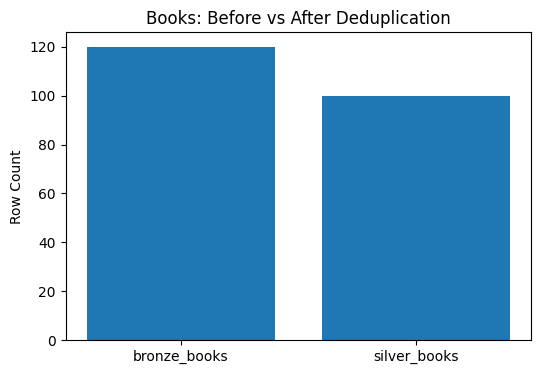

In [14]:
# 📊 4. Nice Plot (Before vs After)

import matplotlib.pyplot as plt

df_compare = con.execute("""
SELECT 'bronze_books' AS stage, COUNT(*) AS rows FROM bronze_books
UNION ALL
SELECT 'silver_books', COUNT(*) FROM silver_books
""").df()

plt.figure(figsize=(6,4))
plt.bar(df_compare["stage"], df_compare["rows"])
plt.title("Books: Before vs After Deduplication")
plt.ylabel("Row Count")
plt.show()

## 📈 5. Business Analysis

```
🔴 Before (Bronze)
	•	~120 rows
	•	includes duplicates
	•	unreliable for joins

🟢 After (Silver)
	•	~100 rows
	•	clean, unique books
	•	safe for dimension modeling
```
⸻

* 🧠 Key Insight (VERY IMPORTANT)

👉 Dimensions must be:

```
	•	clean
	•	unique
	•	stable
```

This is called:

Dimension Integrity

⸻

### 💡 Teaching Moment

Ask students:

“Why don’t we deduplicate the fact table the same way?”

👉 Answer:

```
	•	Fact tables represent events
	•	Duplicates may be real transactions
	•	Needs different logic (not just DISTINCT)
```
⸻

👉 Next Step

* ⚪ CELL 4 — Clean Sales (NULL Handling + Drop Bad Records)

This is where:

```
	•	we start making business decisions on bad data
	•	the most important ETL step begins 🔥
```

---
# ⚪ CELL 4 — Clean Sales (NULL Handling + Drop Bad Records)

This is where:

```
	•	we start making business decisions on bad data
	•	the most important ETL step begins 🔥
```

## ⚪ CELL 4 — Clean Sales (NULL Handling + Drop Bad Records)

* Perfect — this is the most important ETL cell in the entire pipeline. 🔥

* This is where students learn how to make decisions about bad data.


✅ 1. What are we doing?

We are cleaning bronze_sales by:

* Rules:

```
	•	❌ DROP rows where transaction_id IS NULL
	•	✅ FILL discount → 0.00
	•	✅ FILL book_format → 'hard_copy'
```

#### 👉 Output: `silver_sales_step1`

* ⚠️ We are NOT fixing dates yet — that’s next cell

⸻

### 💼 2. Business Value

This step enforces business rules:

|Issue	              | Decision	    |Why |
|---------------------|-----------------|------------------------|
|NULL transaction_id  |  ❌ DROP	    | cannot track transaction
|NULL discount	      | ✅ 0.00	        | means no discount |
|NULL format	      | ✅ hard_copy	| business default |


⸻

### Real-world meaning:
```
	•	A sale without ID = invalid transaction
	•	Missing discount = no promotion applied
	•	Missing format = assume physical product
```
               
* 👉 This is where data engineering meets business logic

⸻

In [15]:
# 🧾 3. SQL

# ----------------------------------------
# Clean sales (Step 1)
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE silver_sales_step1 AS
SELECT
    transaction_id,
    book_id,
    UPPER(TRIM(sale_type)) AS sale_type,
    date_sold,
    year_sold,
    UPPER(TRIM(customer_gender)) AS customer_gender,
    sale_price,

    -- FIX NULL discount
    COALESCE(discount, 0.00) AS discount,

    -- recompute final_price
    ROUND(sale_price - COALESCE(discount, 0.00), 2) AS final_price,

    country_sold,
    city_sold,

    -- FIX NULL format
    COALESCE(book_format, 'hard_copy') AS book_format

FROM bronze_sales
WHERE transaction_id IS NOT NULL
"""

con.execute(query)

# Validate row count
cleaned_rows = con.execute("""
SELECT COUNT(*) AS cleaned_rows
FROM silver_sales_step1
""").df()

cleaned_rows

,cleaned_rows
0,20900


In [16]:
# 🔍 Validation Checks (VERY IMPORTANT)
# Check no NULLs remain in key columns

validation_checks = con.execute("""
SELECT
    SUM(CASE WHEN transaction_id IS NULL THEN 1 ELSE 0 END) AS null_tx,
    SUM(CASE WHEN discount IS NULL THEN 1 ELSE 0 END) AS null_discount,
    SUM(CASE WHEN book_format IS NULL THEN 1 ELSE 0 END) AS null_format
FROM silver_sales_step1
""").df()

validation_checks

### 👉 Expected:
### 0, 0, 0

,null_tx,null_discount,null_format
0,0.0,0.0,0.0


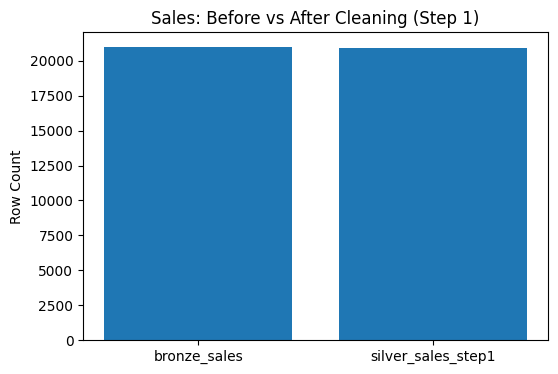

In [17]:
# 📊 4. Nice Plot (Data Reduction)

import matplotlib.pyplot as plt

df_counts = con.execute("""
SELECT 'bronze_sales' AS stage, COUNT(*) AS rows FROM bronze_sales
UNION ALL
SELECT 'silver_sales_step1', COUNT(*) FROM silver_sales_step1
""").df()

plt.figure(figsize=(6,4))
plt.bar(df_counts["stage"], df_counts["rows"])
plt.title("Sales: Before vs After Cleaning (Step 1)")
plt.ylabel("Row Count")
plt.show()

## 📈 5. Business Analysis

```
🔴 Before (Bronze)
	•	includes:
	•	NULL transaction_id ❌
	•	NULL discount ❌
	•	NULL format ❌

🟢 After (Silver Step 1)
	•	all transactions are:
	•	valid
	•	standardized
	•	usable
```
⸻

* 📉 Important Insight

Row count will decrease slightly:

👉 because we dropped invalid transactions

This is expected and correct

⸻

* 🧠 Key Concept (VERY IMPORTANT)

👉 Not all bad data should be fixed

|Type	      |Action |
|---------------|--------|
Recoverable	    | FIX |
Non-recoverable	| DROP |


⸻

* 💡 Teaching Moment

Ask:

“Why don’t we fill missing transaction_id?”

👉 Answer:

```
	•	no reliable way to reconstruct it
	•	would create fake data
```
⸻

* 🚀 Next Step

* ⚪ CELL 5 — Fix Date Formats (CRITICAL ETL STEP)

This is where:

```
	•	your mixed date formats finally get handled
	•	students learn real-world parsing logic
```
    
* 🔥 This one is a big moment in the lecture

---
# ⚪ CELL 5 — Fix Date Formats (Standardization)

* This is a core real-world ETL problem.

* Students usually struggle here → which makes it a great teaching moment. 🔥

* ✅ 1. What are we doing?

* We are: converting mixed date formats into a single standard DATE type

Input formats:

```
	•	YYYY-MM-DD → 2025-10-25
	•	MM/DD/YYYY → 10/25/2025
	•	YYYY/MM/DD → 2025/10/25
```

👉 Output:

```
DATE  → 2025-10-25
```

⸻

### 💼 2. Business Value

Without fixing dates:

```
	•	❌ time-series analysis breaks
	•	❌ grouping by month/year fails
	•	❌ dashboards become inconsistent
```

Example:

`GROUP BY date_sold`

👉 would treat:

```
10/25/2025
2025-10-25
```

as different days ❌

⸻

Real-world impact:

```
	•	incorrect trends
	•	broken forecasting
	•	wrong business decisions
```
⸻

In [18]:
# 🧾 3. SQL (Date Standardization)

# ----------------------------------------
# Fix date formats
#
#  silver_sales_step1 ---> silver_sales
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE silver_sales AS
SELECT
    transaction_id,
    book_id,
    sale_type,

    -- 🔥 CORE LOGIC: parse multiple formats
    COALESCE(
        TRY_STRPTIME(date_sold, '%m/%d/%Y'),
        TRY_STRPTIME(date_sold, '%Y-%m-%d'),
        TRY_STRPTIME(date_sold, '%Y/%m/%d')
    )::DATE AS date_sold,

    year_sold,
    customer_gender,
    sale_price,
    discount,
    final_price,
    country_sold,
    city_sold,
    book_format

FROM silver_sales_step1
"""

con.execute(query)

# Validate
silver_sales_total_rows = con.execute("""
SELECT COUNT(*) AS total_rows
FROM silver_sales
""").df()

silver_sales_total_rows

,total_rows
0,20900


In [19]:
# 🔍 Validation (CRITICAL)

# Check if any dates failed parsing
bad_dates_count = con.execute("""
SELECT COUNT(*) AS bad_dates
FROM silver_sales
WHERE date_sold IS NULL
""").df()

### 👉 Expected:
### bad_dates = 0

bad_dates_count

,bad_dates
0,0


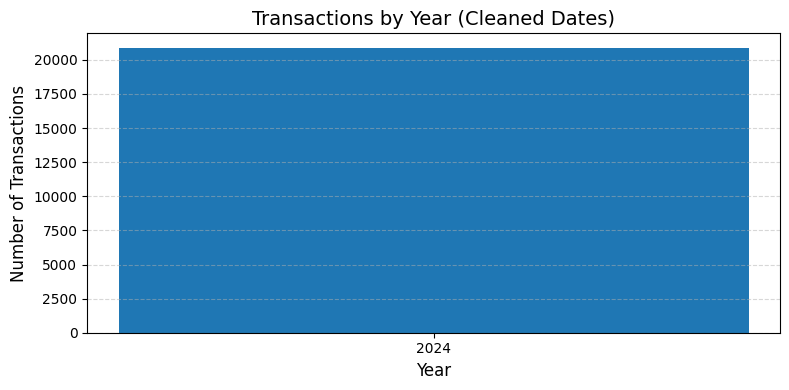

In [20]:
# 📊 4. Nice Plot (Date Distribution)

import matplotlib.pyplot as plt

# Query
df_dates = con.execute("""
SELECT
    YEAR(date_sold) AS year,
    COUNT(*) AS cnt
FROM silver_sales
GROUP BY year
ORDER BY year
""").df()

# Plot
plt.figure(figsize=(8, 4))

plt.bar(df_dates["year"], df_dates["cnt"])

# Titles & labels
plt.title("Transactions by Year (Cleaned Dates)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)

# Improve readability
plt.xticks(df_dates["year"], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tight layout for clean spacing
plt.tight_layout()

plt.show()

⸻

## 📈 5. Business Analysis

```
🔴 Before (Bronze / Step1)
	•	dates are:
	•	inconsistent
	•	unreliable
	•	not analyzable

🟢 After (Silver)
	•	dates are:
	•	standardized
	•	comparable
	•	ready for analytics
```
⸻

* 🧠 Key Insight

👉 Data standardization is mandatory for analytics

This is called: **Data Normalization / Conformance**

⸻

* 💡 Teaching Moment (Very Powerful)

Ask:  “Why don’t we just keep dates as strings?”

👉 Answer:

```
	•	cannot do:
	•	GROUP BY month
	•	ORDER BY time
	•	DATE functions
	•	performance issues
```
⸻

* 🔥 Bonus Question

* Ask students:

* “Why do we use COALESCE + TRY_STRPTIME instead of CASE?”

👉 Answer:

```
	•	cleaner
	•	scalable
	•	handles unknown formats better
```
⸻

🚀 Next Step

⚪ CELL 6 — Remove Duplicate Sales (FACT Table Cleaning)

This is where:

```
	•	students learn the difference between:
	•	dimension dedup
	•	fact dedup (VERY different thinking) 🔥
```

---

# ⚪ CELL 6 — Remove Duplicate Sales (Fact Cleaning)

* Now we hit a subtle but critical concept:

* Deduplicating a FACT table is NOT the same as deduplicating a dimension.

* This is where many analysts get it wrong — so this cell matters a lot. 🔥


* ✅ 1. What are we doing?

We are:

```
	•	removing exact duplicate sales records
	•	creating a trusted transactional dataset
```

👉 Output:  `silver_sales_clean`

⚠️ Important:

```
	•	we remove only true duplicates
	•	we do NOT aggregate
	•	we do NOT group
```
⸻

💼 2. Business Value

Duplicate sales cause:

```
	•	❌ inflated revenue
	•	❌ incorrect KPIs
	•	❌ wrong dashboards
```

Example:

If one sale appears twice:

`$50` → becomes `$100` ❌

👉 This directly leads to:

```
	•	wrong financial reporting
	•	bad decisions
```
⸻

* 🧠 Key Concept (VERY IMPORTANT)

|Table Type	| Dedup Strategy |
|-----------|-----------------|
Dimension	| always deduplicate |
Fact	    | ⚠️ only remove exact duplicates |


⸻

### Why?

Because:

👉 Two rows might look similar but represent real transactions

```
Transaction A → real
Transaction B → real (same values)
```
    
* 👉 You MUST NOT remove those

⸻

In [21]:
# 🧾 3. SQL

# ----------------------------------------
# Remove duplicate sales (exact matches)
#
# silver_sales ---> silver_sales_clean
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE silver_sales_clean AS
SELECT *
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY transaction_id
               ORDER BY date_sold
           ) AS rn
    FROM silver_sales
)
WHERE rn = 1
"""

con.execute(query)

# Validate
cleaned_rows = con.execute("""
SELECT COUNT(*) AS cleaned_rows
FROM silver_sales_clean
""").df()

cleaned_rows

,cleaned_rows
0,20000


In [22]:
# 🔍 Validation (VERY IMPORTANT)
# Check if duplicates still exist

validation_rows = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT transaction_id) AS unique_transactions
FROM silver_sales_clean
""").df()

validation_rows


,total_rows,unique_transactions
0,20000,20000


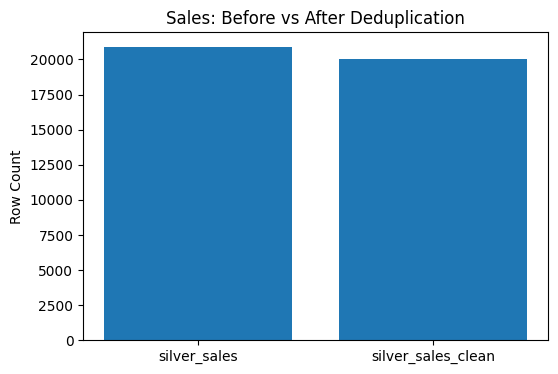

In [23]:
# 📊 4. Nice Plot (Before vs After)

import matplotlib.pyplot as plt

df_counts = con.execute("""
SELECT 'silver_sales' AS stage, COUNT(*) AS rows FROM silver_sales
UNION ALL
SELECT 'silver_sales_clean', COUNT(*) FROM silver_sales_clean
""").df()

plt.figure(figsize=(6,4))
plt.bar(df_counts["stage"], df_counts["rows"])
plt.title("Sales: Before vs After Deduplication")
plt.ylabel("Row Count")
plt.show()

⸻

## 📈 5. Business Analysis

```
🔴 Before
	•	duplicate transactions present
	•	revenue inflated
	•	unreliable metrics

🟢 After
	•	each transaction is unique
	•	revenue becomes accurate
	•	analytics becomes trustworthy
```

⸻

### 🧠 Critical Insight (EXAM-LEVEL)

```
👉 DISTINCT is safe ONLY IF:
	•	duplicates are exact copies
```
⸻

### 💡 Teaching Moment

Ask:

“What if two different transactions have the same values?”

```
👉 Answer:
	•	DISTINCT will collapse them ❌
	•	but they are real events
```

👉 This leads to:

“What is the TRUE primary key of a fact table?”

Answer:

transaction_id


⸻

### ⚠️ Advanced Note (for you)

```
In real systems, better approach:

PARTITION BY transaction_id

instead of full DISTINCT

But for teaching:
👉 DISTINCT is perfect
```
⸻

🚀 Next Step

🟡 CELL 7 — Create dim_book

```
This is where:
	•	we transition from Silver → Gold
	•	dimensional modeling officially begins 🔥
Explain the step.
```

---
# 🟡 CELL 7 — Create dim_book (First Dimension Table)

* Excellent — now we enter the Gold Layer 🔥

* This is where everything you’ve done finally turns into a Star Schema.



### ✅ 1. What are we doing?

```
We are:
	•	transforming silver_books into a dimension table
	•	creating: dim_book
```

👉 This will be used by the fact table via:

`book_id` (foreign key)


⸻

💼 2. Business Value

```
This table answers:
	•	What books are we selling?
	•	What genres perform best?
	•	Who are the authors?
	•	Which publishers drive revenue?
```
⸻

Why dimension tables matter:

```
Without dim_book:
	•	❌ data is duplicated in fact table
	•	❌ queries are messy
	•	❌ analytics is slow

With dim_book:
	•	✅ clean joins
	•	✅ reusable attributes
	•	✅ scalable analytics
```
⸻

### 🧠 Key Concept

* Dimension tables describe facts

In [24]:
#🧾 3. SQL

# ----------------------------------------
# Create dim_book
#
# silver_books --> dim_book
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE dim_book AS
SELECT
    book_id,
    book_title,
    book_genre,
    author_id,
    author_name,
    author_gender,
    author_web_site,
    published_date,
    publisher
FROM silver_books
ORDER BY book_id
"""

con.execute(query)

# Validate
dim_book_rows = con.execute("""
SELECT COUNT(*) AS dim_book_rows
FROM dim_book
""").df()

dim_book_rows

,dim_book_rows
0,100


In [25]:
# 🔍 Validation (VERY IMPORTANT)

# Ensure uniqueness of book_id
con.execute("""
SELECT COUNT(*) AS duplicate_books
FROM (
    SELECT book_id, COUNT(*) AS cnt
    FROM dim_book
    GROUP BY book_id
    HAVING COUNT(*) > 1
)
""").df()

### 👉 Expected:
### duplicate_books = 0

,duplicate_books
0,0


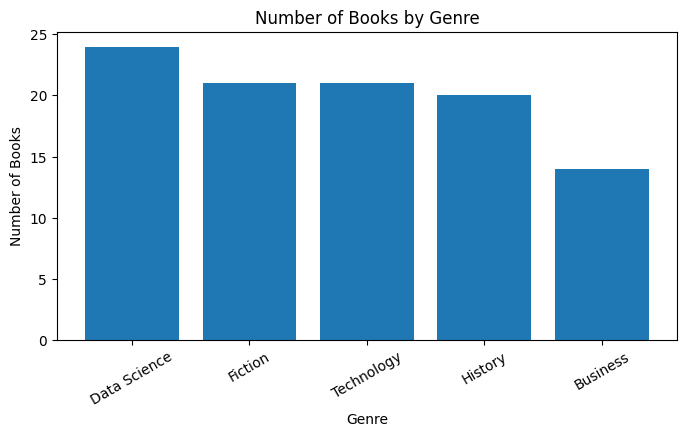

In [26]:
# 📊 4. Nice Plot (Books by Genre)

import matplotlib.pyplot as plt

df_genre = con.execute("""
SELECT
    book_genre,
    COUNT(*) AS num_books
FROM dim_book
GROUP BY book_genre
ORDER BY num_books DESC
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_genre["book_genre"], df_genre["num_books"])
plt.title("Number of Books by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.xticks(rotation=30)
plt.show()

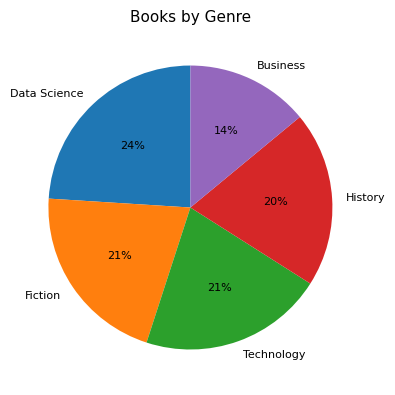

In [27]:
# ✅ Nice Pie Chart Version (Lecture-Quality)
import matplotlib.pyplot as plt

df_genre = con.execute("""
SELECT
    book_genre,
    COUNT(*) AS num_books
FROM dim_book
GROUP BY book_genre
ORDER BY num_books DESC
""").df()

# Compact but readable
plt.figure(figsize=(4, 4))

plt.pie(
    df_genre["num_books"],
    labels=df_genre["book_genre"],   # 👈 bring labels back
    autopct='%1.0f%%',
    startangle=90,
    textprops={'fontsize': 8}        # 👈 smaller font to fit
)

plt.title("Books by Genre", fontsize=11)

plt.tight_layout(pad=0.5)
plt.show()

## 📈 5. Business Analysis

```
Insights you can extract:
	•	Which genres dominate catalog
	•	Balance of content (technical vs fiction)
	•	Diversity of offerings
```

⸻

```
Example interpretation:
	•	If Data Science dominates → strong technical focus
	•	If Fiction dominates → mass-market strategy
```
⸻

* 🧠 Key Insight

```
👉 dim_book is:
	•	small
	•	clean
	•	stable
```

This is exactly what a dimension should be.

⸻

### 💡 Teaching Moment

Ask students:

“Why don’t we store book_title inside the fact table?”

```
👉 Answer:
	•	duplication
	•	storage waste
	•	update anomalies
```
⸻

### 🔥 Bonus Insight

```
If author name changes:
	•	in dimension → update once ✅
	•	in fact table → update thousands ❌
```
⸻

### 🚀 Where you are now

```
You have:
	•	✅ Clean fact data
	•	✅ First dimension table

👉 You are officially in Star Schema territory
```
⸻

### 👉 Next Step: Next we build:

🟡 `dim_location`

```
This introduces:
	•	geographic analytics
	•	grouping logic
	•	surrogate keys (VERY IMPORTANT 🔥)
```

---
# 🟡 CELL 8 — Create dim_location (Geographic Dimension)

* This is a big modeling step. 🔥

* You’re introducing surrogate keys and true dimensional design.

⸻

### ✅ 1. What are we doing?

We are:

```
    1. extracting unique (country, city) combinations
    2. creating a dimension table
    3. assigning a surrogate key: `location_id`
    4. 👉 Output: `dim_location` table
```
⸻

### 💼 2. Business Value

```
This table enables:
	•	revenue by country 🌍
	•	sales by city 🏙️
	•	regional comparisons
	•	geographic dashboards

Why not keep country/city in fact table?
	•	❌ repeated thousands of times
	•	❌ inefficient
	•	❌ harder to maintain

👉 Instead:

store once in dimension, reference via key
    
```
⸻

### 🧠 Key Concept (VERY IMPORTANT)

```
    Surrogate Key: location_id (generated)

    Instead of: (country, city)
```

⸻

### Why?
```
	•	faster joins
	•	smaller storage
	•	stable identifiers
```

In [28]:
# 🧾 3. SQL

# ----------------------------------------
# Create dim_location
#
#  silver_sales_clean --> dim_location
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE dim_location AS
SELECT
    ROW_NUMBER() OVER (ORDER BY country_sold, city_sold) 
      AS location_id,
    country_sold AS country,
    city_sold AS city
FROM (
    SELECT DISTINCT country_sold, city_sold
    FROM silver_sales_clean
)
ORDER BY country, city
"""

con.execute(query)

# Validate
all_locations = con.execute("""
SELECT location_id, country, city 
FROM dim_location
ORDER BY location_id
""").df()

all_locations

,location_id,country,city
0,1,Australia,Brisbane
1,2,Australia,Melbourne
2,3,Australia,Sydney
3,4,Canada,Calgary
4,5,Canada,Montreal
5,6,Canada,Toronto
6,7,Canada,Vancouver
7,8,Germany,Berlin
8,9,Germany,Frankfurt
9,10,Germany,Hamburg


In [29]:
# 🔍 Validation (VERY IMPORTANT)

# Ensure uniqueness of (country, city)
con.execute("""
SELECT COUNT(*) AS duplicates
FROM (
    SELECT country, city, COUNT(*) AS cnt
    FROM dim_location
    GROUP BY country, city
    HAVING COUNT(*) > 1
)
""").df()

### 👉 Expected:
### duplicates = 0

,duplicates
0,0


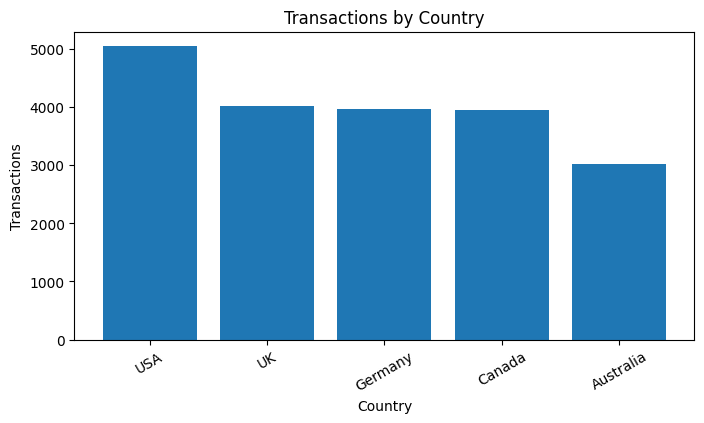

In [30]:
# 📊 4. Nice Plot (Transactions by Country)

import matplotlib.pyplot as plt

df_country = con.execute("""
SELECT
    country_sold AS country,
    COUNT(*) AS transactions
FROM silver_sales_clean
GROUP BY country_sold
ORDER BY transactions DESC
""").df()

plt.figure(figsize=(8,4))
plt.bar(df_country["country"], df_country["transactions"])
plt.title("Transactions by Country")
plt.xlabel("Country")
plt.ylabel("Transactions")
plt.xticks(rotation=30)
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	Which countries generate most sales
	•	Market distribution
	•	Regional demand

⸻

Example interpretation:
	•	USA dominates → strong core market
	•	Emerging countries → growth opportunities

⸻

🧠 Key Insight

👉 dim_location is:
	•	small
	•	unique
	•	reusable

⸻

💡 Teaching Moment (VERY IMPORTANT)

Ask:

“Why do we create location_id instead of using (country, city)?”

Expected answers:
	•	performance
	•	simplicity
	•	scalability

⸻

🔥 Advanced Insight (Nice to mention)

This step is:

Denormalization → Controlled Normalization

We:
	•	extract repeating attributes
	•	centralize them

⸻

🚀 Where you are now

You have:
	•	✅ dim_book
	•	✅ dim_location

👉 You now have multiple dimensions

⸻

👉 Next Step: “Cell 9”

Next we build:

🟡 dim_date

This is one of the most important dimensions in DW 🔥
	•	time-series analysis
	•	grouping by month/year
	•	OLAP capabilities

This is a big concept cell 🚀

```

---
# Top-10 Cities

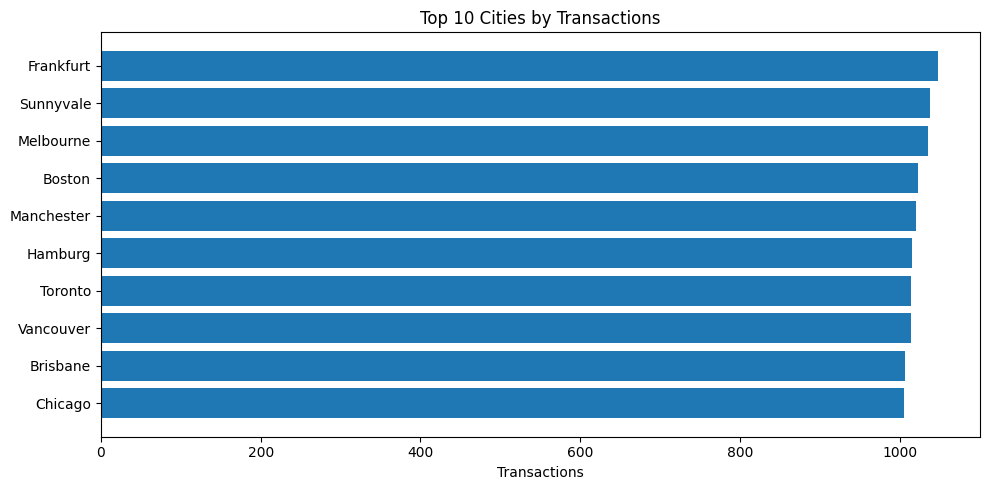

In [31]:
df_city = con.execute("""
SELECT
    city_sold AS city,
    COUNT(*) AS transactions
FROM silver_sales_clean
GROUP BY city_sold
ORDER BY transactions DESC
LIMIT 10
""").df()

plt.figure(figsize=(10,5))
plt.barh(df_city["city"], df_city["transactions"])

plt.title("Top 10 Cities by Transactions")
plt.xlabel("Transactions")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 🟡 CELL 9 — Create dim_date (Time Dimension)


```
This is one of the most important cells in all of Data Warehousing. 🔥

⸻

🟡 CELL 9 — Create dim_date (Time Dimension)

⸻

✅ 1. What are we doing?

We are:
	•	extracting unique dates from transactions
	•	creating a time dimension table
	•	enriching it with attributes:

year, month, day, day_name, quarter

👉 Output:

dim_date


⸻

💼 2. Business Value

This table enables:
	•	📈 time-series analysis
	•	📅 monthly trends
	•	📊 seasonal insights
	•	🧠 forecasting

⸻

Without dim_date:
	•	❌ repeated date calculations
	•	❌ messy queries
	•	❌ slow analytics

⸻

With dim_date:
	•	✅ clean joins
	•	✅ reusable time attributes
	•	✅ OLAP-ready

⸻

🧠 Key Concept (VERY IMPORTANT)

Time is the most important dimension in analytics

```

In [32]:
# 🧾 3. SQL

# ----------------------------------------
# Create dim_date
#
# silver_sales_clean --> dim_date
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY date_sold) AS date_id,
    date_sold,

    YEAR(date_sold)   AS year,
    MONTH(date_sold)  AS month,
    DAY(date_sold)    AS day,

    DAYNAME(date_sold) AS day_name,
    QUARTER(date_sold) AS quarter

FROM (
    SELECT DISTINCT date_sold
    FROM silver_sales_clean
)
ORDER BY date_sold
"""

con.execute(query)

# Validate
date_rows = con.execute("""
SELECT COUNT(*) AS date_rows
FROM dim_date
""").df()

date_rows

,date_rows
0,366


In [33]:
# 🔍 Validation (VERY IMPORTANT)
# Ensure uniqueness of date

dates_duplicates = con.execute("""
SELECT COUNT(*) AS duplicates
FROM (
    SELECT date_sold, COUNT(*) AS cnt
    FROM dim_date
    GROUP BY date_sold
    HAVING COUNT(*) > 1
)
""").df()

### 👉 Expected:
### dates_duplicates = 0


dates_duplicates

,duplicates
0,0


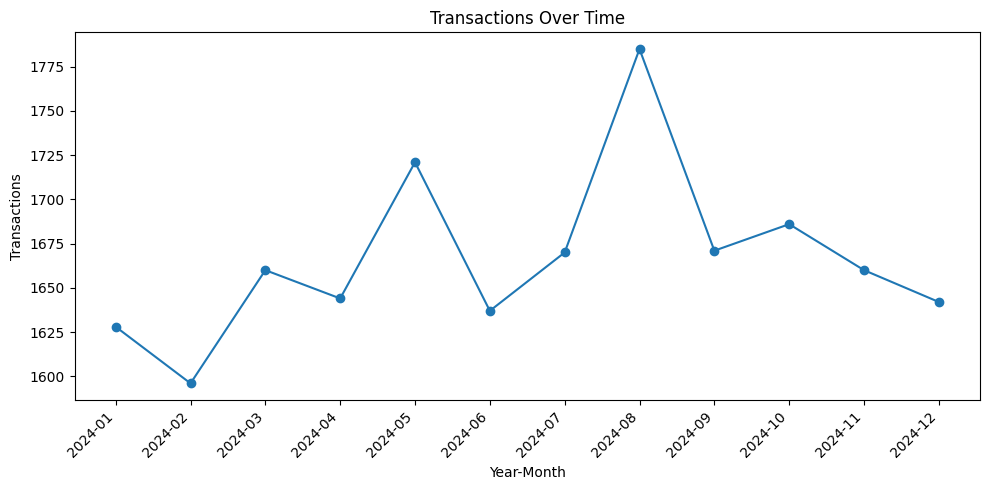

In [34]:
# 📊 4. Nice Plot (Transactions by Month)

import matplotlib.pyplot as plt

df_month = con.execute("""
SELECT
    d.year,
    d.month,
    COUNT(*) AS transactions
FROM silver_sales_clean s
JOIN dim_date d
  ON s.date_sold = d.date_sold
GROUP BY d.year, d.month
ORDER BY d.year, d.month
""").df()

df_month["year_month"] = df_month["year"].astype(str) + "-" + df_month["month"].astype(str).str.zfill(2)

plt.figure(figsize=(10,5))
plt.plot(df_month["year_month"], df_month["transactions"], marker="o")

plt.title("Transactions Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 📈 5. Business Analysis

```
Insights:
	•	detect seasonality
	•	identify growth trends
	•	find peak periods

⸻

Example interpretation:
	•	spikes → promotions / holidays
	•	dips → low demand periods
	•	steady growth → healthy business

⸻

🧠 Key Insight

👉 dim_date turns raw timestamps into:

analyzable business time

⸻

💡 Teaching Moment (VERY STRONG)

Ask:

“Why don’t we compute YEAR() and MONTH() on the fly?”

👉 Answer:
	•	repeated computation ❌
	•	inconsistent logic ❌
	•	slower queries ❌

👉 Precomputing = faster + cleaner

⸻

🔥 Advanced Insight

This is called:

Conformed Time Dimension

Used across:
	•	sales
	•	marketing
	•	finance

⸻

🚀 Where you are now

You have:
	•	✅ dim_book
	•	✅ dim_location
	•	✅ dim_date

👉 You now have full dimensional coverage

⸻

👉 Next Step

Say: “Cell 10”

Now we build:

🟡 fact_sales (FINAL STAR SCHEMA TABLE)

This is where everything comes together 🔥
```

---
# 🟡 CELL 10 — Create fact_sales <br> (Final Star Schema Table)

```
This is the moment everything comes together. 🔥

You’re now building the FACT table, the center of the Star Schema.


⸻

✅ 1. What are we doing?

We are:
	•	joining cleaned sales (Silver) with dimension tables (Gold)
	•	replacing descriptive fields with foreign keys

👉 Output:

fact_sales


⸻

🧠 Fact Table Grain (VERY IMPORTANT)

1 row = 1 transaction


⸻

💼 2. Business Value

This table enables:
	•	revenue analysis 💰
	•	customer behavior insights 👥
	•	geographic trends 🌍
	•	time-based analytics 📅

⸻

Why this matters

Before:
	•	messy raw tables ❌

After:
	•	clean, joinable, scalable model ✅
```

In [35]:
#🧾 3. SQL

# ----------------------------------------
# Create fact_sales
#
# { silver_sales_clean, dim_book, dim_location, dim_date } --> fact_sales
# ----------------------------------------

query = """
CREATE OR REPLACE TABLE fact_sales AS
SELECT
    s.transaction_id,

    -- Foreign Keys
    d.date_id,
    b.book_id,
    l.location_id,

    -- Degenerate / attributes
    s.sale_type,
    s.customer_gender,
    s.book_format,

    -- Measures
    1 AS quantity_sold,
    s.sale_price,
    s.discount,
    s.final_price

FROM silver_sales_clean s

JOIN dim_book b
  ON s.book_id = b.book_id

JOIN dim_location l
  ON s.country_sold = l.country
 AND s.city_sold = l.city

JOIN dim_date d
  ON s.date_sold = d.date_sold

ORDER BY s.transaction_id
"""

con.execute(query)

# Validate
fact_rows_count = con.execute("""
SELECT COUNT(*) AS fact_rows
FROM fact_sales
""").df()


fact_rows_count

,fact_rows
0,20000


In [36]:
# 🔍 Validation (VERY IMPORTANT)
# Check referential integrity

total_rows = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT transaction_id) AS unique_tx
FROM fact_sales
""").df()

### 👉 Expected:
### total_rows = unique_tx = 20000

total_rows

,total_rows,unique_tx
0,20000,20000


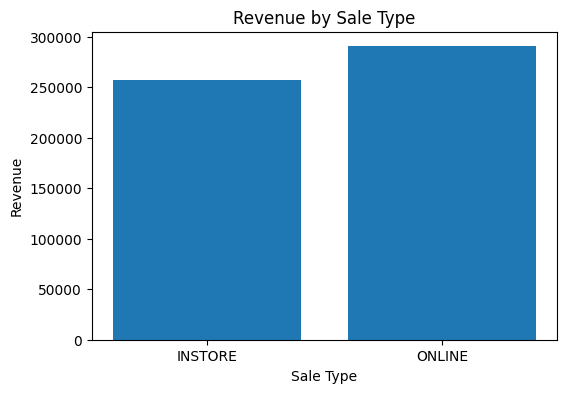

In [37]:
# 📊 4. Nice Plot (Revenue by Sale Type: INSTORE vs ONLINE)

import matplotlib.pyplot as plt

df_sales_type = con.execute("""
SELECT
    sale_type,
    SUM(final_price) AS revenue
FROM fact_sales
GROUP BY sale_type
""").df()

plt.figure(figsize=(6,4))
plt.bar(df_sales_type["sale_type"], df_sales_type["revenue"])

plt.title("Revenue by Sale Type")
plt.xlabel("Sale Type")
plt.ylabel("Revenue")

plt.show()

## 📈 5. Business Analysis

* Insights:
```
	•	ONLINE vs INSTORE performance
	•	channel effectiveness
	•	customer preferences
```
⸻ 

* Example interpretation:
```
	•	ONLINE dominates → strong e-commerce
	•	INSTORE strong → retail still relevant
```
⸻

### 🧠 Key Insight (VERY IMPORTANT)

* 👉 Fact table contains:
```
   Measures:  sale_price, discount, final_price

   Foreign Keys: date_id, book_id, location_id
```

⸻

### 💡 Teaching Moment (VERY STRONG)

Ask:

“Why don’t we keep country and book_title in fact_sales?”

👉 Answer:
```
	•	duplication ❌
	•	larger table ❌
	•	slower joins ❌
```
⸻

### 🔥 Star Schema Achieved

You now have:

```

             dim_book
                |
                |
             fact_sales 
            /         \
           /           \
         dim_date      dim_location
```

⸻

### 🚀 Where you are now

```
You have successfully built:
	•	✅ Bronze layer
	•	✅ Silver layer
	•	✅ Gold layer
	•	✅ Star Schema
```
⸻

* 🎯 Next Step

Now we start:

* 📊 BI / OLAP Queries

* This is where students see the real power of everything you built 🔥


---
# 📊 CELL 11 — BI Query 1: Revenue by Book Genre

```
Perfect — now we enter the fun part: BI / OLAP 🔥

This is where students finally see why we built the star schema.

⸻

📊 CELL 11 — BI Query 1: Revenue by Book Genre

⸻

✅ 1. What are we doing?

We are:
	•	aggregating revenue
	•	grouping by book genre

👉 This is a classic OLAP aggregation

⸻

💼 2. Business Value

This answers:

“Which genres generate the most revenue?”

⸻

Why this matters:
	•	inventory planning 📦
	•	marketing focus 🎯
	•	publisher strategy 📚
```

In [38]:
#🧾 3. SQL: using "star schema tables"

query = """
SELECT
    b.book_genre,
    ROUND(SUM(f.final_price), 2) AS total_revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_genre
ORDER BY total_revenue DESC
"""

df_genre = con.execute(query).df()
df_genre

,book_genre,total_revenue
0,Data Science,130087.49
1,Fiction,116390.68
2,Technology,112373.09
3,History,112042.37
4,Business,76659.35


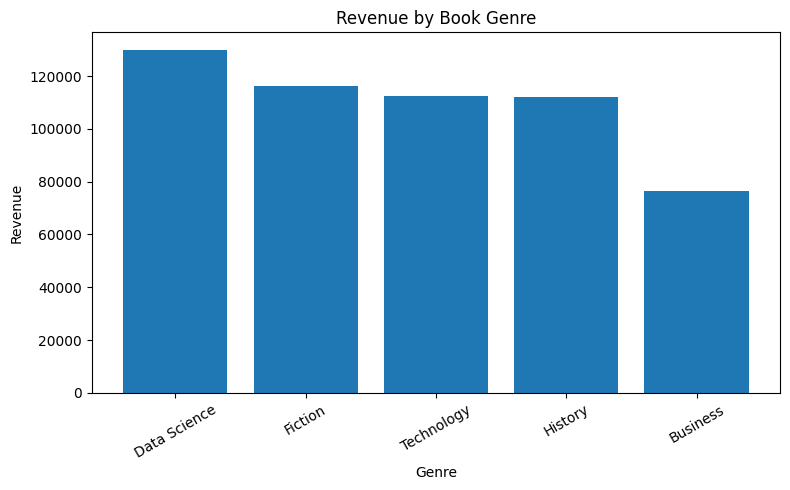

In [39]:
#📊 4. Nice Plot (Revenue by Genre)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df_genre["book_genre"], df_genre["total_revenue"])

plt.title("Revenue by Book Genre")
plt.xlabel("Genre")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	Top genre = main revenue driver
	•	Low genres = growth opportunity or weak category

⸻

Example interpretation:
	•	Data Science dominates → strong technical demand
	•	Fiction low → may need promotion

⸻

🧠 Key Insight

👉 This query uses:
	•	Fact table → measures
	•	Dimension table → grouping

⸻

💡 Teaching Moment (VERY STRONG)

Ask:

“Why don’t we store genre in fact_sales?”

👉 Answer:
	•	duplication ❌
	•	normalization violation ❌
	•	harder to maintain ❌

⸻

🔥 OLAP Concept Introduced

This is:

ROLL-UP (aggregation)

⸻

🚀 Where you are now

You just demonstrated:
	•	first real BI query
	•	power of joins + dimensions

⸻

👉 Next Step: “Cell 12”

Next we do:

📊 BI Query 2 — "Top 10 Books by Revenue"

This introduces:
	•	ranking
	•	top-N queries
	•	business prioritization 🔥
```

---
# 📊 CELL 12 — BI Query 2: <br> Top 10 Books by Revenue

```
Great — now we move into ranking + prioritization, 
which is where BI becomes actionable. 🔥

⸻

📊 CELL 12 — BI Query 2: Top 10 Books by Revenue

⸻

✅ 1. What are we doing?

We are:
	•	calculating total revenue per book
	•	ranking books
	•	selecting Top 10

👉 This is a Top-N OLAP query

⸻

💼 2. Business Value

This answers:

“Which books are our best sellers?”

⸻

Why this matters:
	•	promotions & featured listings 🎯
	•	inventory decisions 📦
	•	publisher negotiations 🤝

```

In [40]:
# 🧾 3. SQL

query = """
SELECT
    b.book_title,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_title
ORDER BY revenue DESC
LIMIT 10
"""

df_top_books = con.execute(query).df()
df_top_books

,book_title,revenue
0,Book 98,6606.62
1,Book 78,6533.16
2,Book 75,6151.43
3,Book 73,6145.68
4,Book 67,6145.32
5,Book 19,6076.17
6,Book 7,6033.87
7,Book 16,6025.63
8,Book 43,6003.93
9,Book 52,5989.32


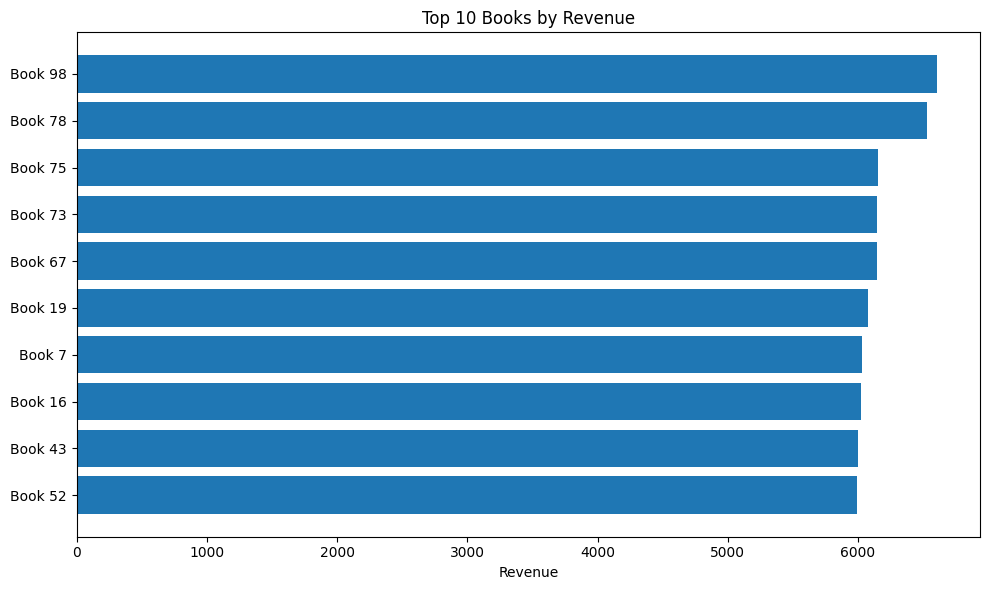

In [41]:
# 📊 4. Nice Plot (Top 10 Books)
# 👉 Recommended: Horizontal Bar (cleaner)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df_top_books["book_title"], df_top_books["revenue"])

plt.title("Top 10 Books by Revenue")
plt.xlabel("Revenue")

plt.gca().invert_yaxis()  # highest on top
plt.tight_layout()
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	identifies revenue-driving products
	•	highlights top performers
	•	reveals long-tail vs winners

⸻

Example interpretation:
	•	Top 3 books dominate → concentration risk
	•	Even distribution → healthy portfolio

⸻

🧠 Key Insight

👉 This query combines:
	•	aggregation (SUM)
	•	sorting (ORDER BY)
	•	filtering (LIMIT)

⸻

💡 Teaching Moment

Ask:

“Why don’t we just use COUNT(*) instead of SUM(final_price)?”

👉 Answer:
	•	COUNT = popularity
	•	SUM = revenue

👉 These answer different business questions

⸻

## 🔥 Optional Upgrade (Advanced — nice touch)
## Add ranking:
```

In [42]:
query = """
SELECT
    b.book_title,
    ROUND(SUM(f.final_price), 2) AS revenue,
    RANK() OVER (ORDER BY SUM(f.final_price) DESC) AS rank
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_title
ORDER BY revenue DESC
LIMIT 10
"""

con.execute(query).df()

,book_title,revenue,rank
0,Book 98,6606.62,1
1,Book 78,6533.16,2
2,Book 75,6151.43,3
3,Book 73,6145.68,4
4,Book 67,6145.32,5
5,Book 19,6076.17,6
6,Book 7,6033.87,7
7,Book 16,6025.63,8
8,Book 43,6003.93,9
9,Book 52,5989.32,10


--
# 🧠 OLAP Concept

```
This is:

Top-N / Ranking Analysis

⸻

🚀 Where you are now

You’ve shown:
	•	aggregation ✔️
	•	grouping ✔️
	•	ranking ✔️

⸻

👉 Next Step:  “Cell 13”

Next we do:

📊 BI Query 3 — Revenue by Country

This introduces:
	•	geographic analysis 🌍
	•	dimension-driven grouping
	•	business expansion insights 🔥
```

---
# 📊 CELL 13 — BI Query 3: <br> Revenue by Country

```
Perfect — now we move into geographic analytics, 
which is one of the most common BI use cases. 🌍🔥

⸻

📊 CELL 13 — BI Query 3: Revenue by Country

⸻

✅ 1. What are we doing?

We are:
	•	aggregating revenue
	•	grouping by country

👉 This is a classic dimension-based aggregation

⸻

💼 2. Business Value

This answers:

“Which countries generate the most revenue?”

⸻

Why this matters:
	•	market prioritization 🌍
	•	expansion strategy 🚀
	•	regional performance tracking 📊

⸻
```

In [43]:
# 🧾 3. SQL

query = """
SELECT
    l.country,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
JOIN dim_location l
  ON f.location_id = l.location_id
GROUP BY l.country
ORDER BY revenue DESC
"""

df_country_rev = con.execute(query).df()
df_country_rev

,country,revenue
0,USA,138442.05
1,UK,110922.56
2,Germany,108113.78
3,Canada,108073.25
4,Australia,82001.34


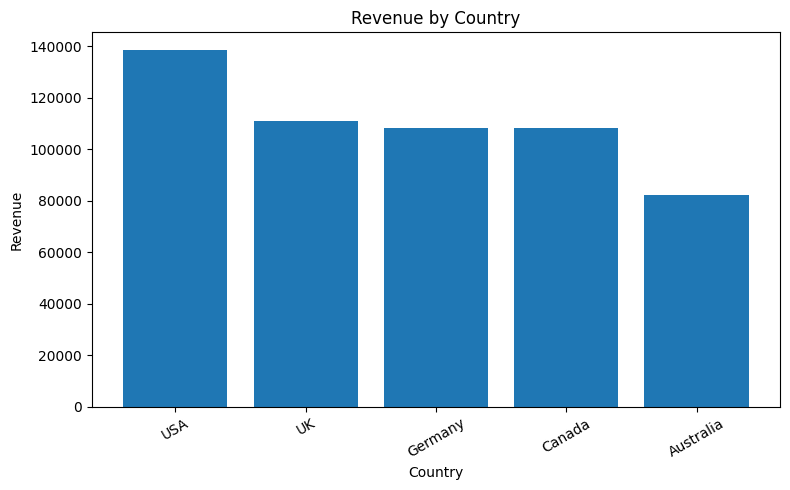

In [44]:
# 📊 4. Nice Plot (Revenue by Country)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df_country_rev["country"], df_country_rev["revenue"])

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 🔥 Optional Upgrade (Very Nice for Slides)
## Pie Chart

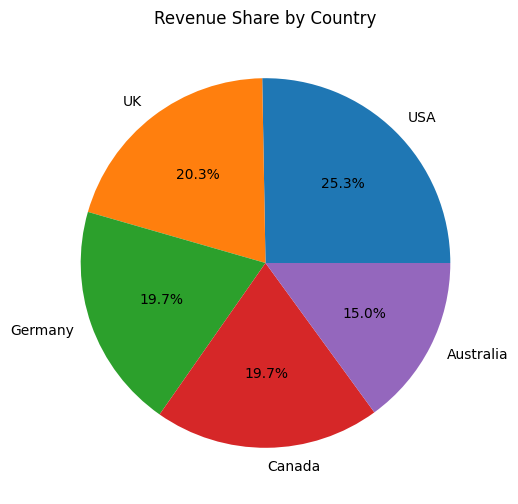

In [45]:
plt.figure(figsize=(6,6))
plt.pie(df_country_rev["revenue"],
        labels=df_country_rev["country"],
        autopct='%1.1f%%')

plt.title("Revenue Share by Country")
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	top countries = core markets
	•	low countries = growth opportunities

⸻

Example interpretation:
	•	USA dominates → mature market
	•	UK/Canada strong → stable expansion
	•	smaller countries → emerging potential

⸻

🧠 Key Insight

👉 This query shows:

How dimensions enable slicing the business

⸻

💡 Teaching Moment

Ask:

“Why do we join dim_location instead of using country directly?”

👉 Answer:
	•	normalization
	•	flexibility
	•	reusable dimensions

⸻

🔥 OLAP Concept

This is:

Slice (by geography)

⸻

🚀 Where you are now

You’ve now shown:
	•	product analytics ✔️
	•	ranking ✔️
	•	geographic analytics ✔️

⸻

👉 Next Step: “Cell 14”

Next we do:

📊 BI Query 4 — Monthly Revenue Trend

This introduces:
	•	time-series analysis 📅
	•	trend detection 📈
	•	real business storytelling 🔥
```

---
# 📊 CELL 14 — BI Query 4: <br> Monthly Revenue Trend

```
This is where analytics becomes storytelling over time. 📈🔥


✅ 1. What are we doing?

We are:
	•	aggregating revenue over time
	•	grouping by year + month

👉 This is time-series analysis

⸻

💼 2. Business Value

This answers:

“How is our business evolving over time?”

⸻

Why this matters:
	•	detect growth 📈
	•	identify seasonality 📅
	•	evaluate promotions 🎯
	•	forecast demand 🔮

```

In [46]:
# 🧾 3. SQL

query = """
SELECT
    d.year,
    d.month,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
JOIN dim_date d
  ON f.date_id = d.date_id
GROUP BY d.year, d.month
ORDER BY d.year, d.month
"""

df_month_rev = con.execute(query).df()

# Create a proper label
df_month_rev["year_month"] = (
    df_month_rev["year"].astype(str) + "-" +
    df_month_rev["month"].astype(str).str.zfill(2)
)

df_month_rev

,year,month,revenue,year_month
0,2024,1,43949.59,2024-01
1,2024,2,42867.73,2024-02
2,2024,3,45851.59,2024-03
3,2024,4,45168.71,2024-04
4,2024,5,47261.37,2024-05
5,2024,6,44335.06,2024-06
6,2024,7,45604.01,2024-07
7,2024,8,49951.06,2024-08
8,2024,9,45210.52,2024-09
9,2024,10,46403.65,2024-10


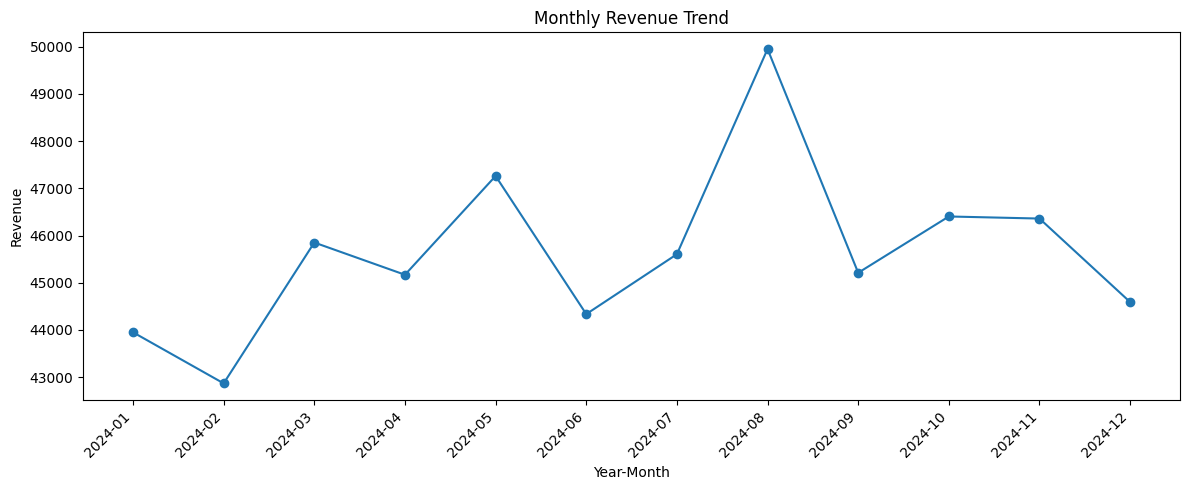

In [47]:
# 📊 4. Nice Plot (Line Chart — VERY IMPORTANT)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_month_rev["year_month"],
         df_month_rev["revenue"],
         marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	identify growth trend
	•	detect seasonality
	•	find peaks and dips

⸻

Example interpretation:
	•	steady growth → healthy business
	•	spikes → promotions / holidays
	•	dips → low demand periods

⸻

🧠 Key Insight

👉 This query uses:
	•	dim_date → time intelligence
	•	fact_sales → revenue

⸻

💡 Teaching Moment (VERY STRONG)

Ask:

“Why didn’t we group by date_sold directly?”

👉 Answer:
	•	no structure ❌
	•	no hierarchy ❌
	•	messy grouping ❌

👉 dim_date provides:

year → month → day


⸻

🔥 OLAP Concept

This is:

Time-series / Trend Analysis
```

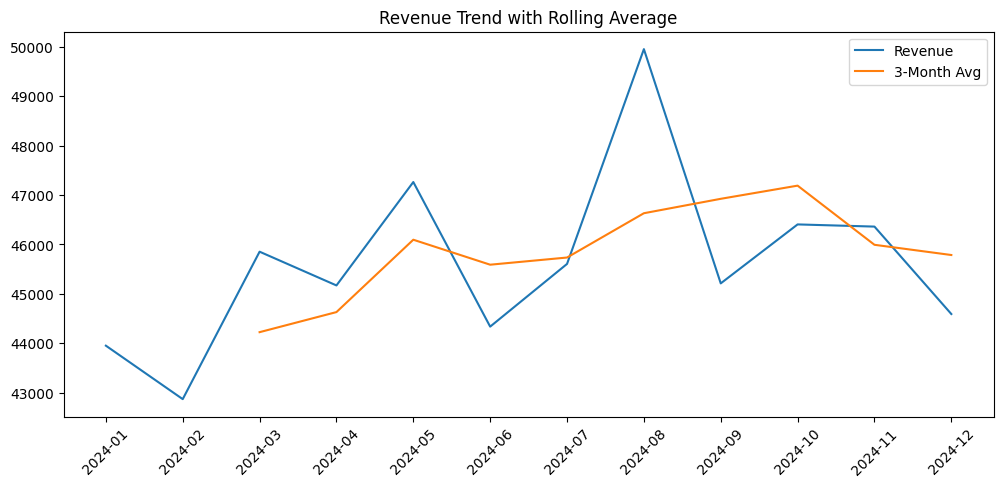

In [48]:
# 🚀 Optional Upgrade (VERY NICE)

# Add smoothing:

df_month_rev["rolling_avg"] = df_month_rev["revenue"].rolling(3).mean()

plt.figure(figsize=(12,5))
plt.plot(df_month_rev["year_month"], df_month_rev["revenue"], label="Revenue")
plt.plot(df_month_rev["year_month"], df_month_rev["rolling_avg"], label="3-Month Avg")

plt.legend()
plt.xticks(rotation=45)
plt.title("Revenue Trend with Rolling Average")
plt.show()

## 🧠 Advanced Insight

```
This is the foundation for:
	•	forecasting models
	•	anomaly detection
	•	business planning

⸻

🚀 Where you are now

You’ve now covered:
	•	product analytics ✔️
	•	ranking ✔️
	•	geography ✔️
	•	time-series ✔️

👉 You’ve hit the 4 pillars of analytics

⸻

👉 Next Step: “Cell 15”

Next we do:

📊 BI Query 5 — Revenue by Book Format

This introduces:
	•	categorical comparison
	•	customer behavior insights
	•	pie chart storytelling 🔥
```

--
# 📊 CELL 15 — BI Query 5: <br> Revenue by Book Format

```
This one is great for customer behavior + storytelling visuals. 🔥

Also introduces categorical comparison cleanly.

⸻

✅ 1. What are we doing?

We are:
	•	aggregating revenue
	•	grouping by book format

hard_copy, paperback, soft_copy

👉 This is categorical analysis

⸻

💼 2. Business Value

This answers:

“What format do customers prefer?”

⸻

Why this matters:
	•	production planning 🏭
	•	inventory strategy 📦
	•	digital vs physical shift 💻📚

In [49]:
# 🧾 3. SQL

query = """
SELECT
    f.book_format,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
GROUP BY f.book_format
ORDER BY revenue DESC
"""

df_format = con.execute(query).df()
df_format

,book_format,revenue
0,soft_copy,199098.58
1,paperback,183116.88
2,hard_copy,165337.52


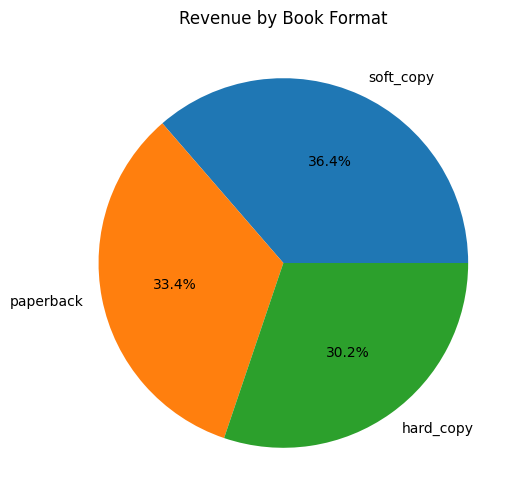

In [50]:
# 📊 4. Nice Plot (Pie Chart — very effective)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(df_format["revenue"],
        labels=df_format["book_format"],
        autopct='%1.1f%%')

plt.title("Revenue by Book Format")
plt.show()

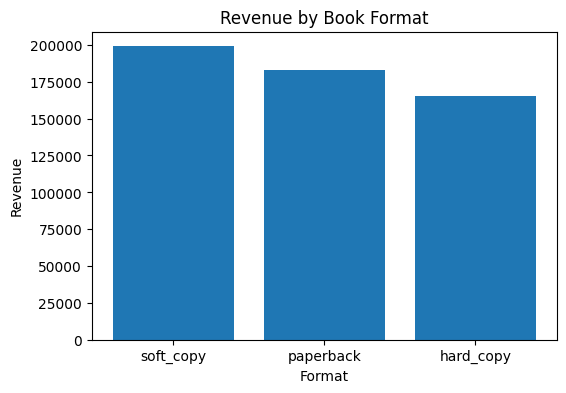

In [51]:
# 🔥 Alternative (Bar Chart — more precise)

plt.figure(figsize=(6,4))
plt.bar(df_format["book_format"], df_format["revenue"])

plt.title("Revenue by Book Format")
plt.xlabel("Format")
plt.ylabel("Revenue")

plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	which format dominates
	•	relative share across formats
	•	customer preference trends

⸻

Example interpretation:
	•	hard_copy dominates → strong physical demand
	•	soft_copy growing → digital adoption
	•	paperback middle → balanced option

⸻

🧠 Key Insight

👉 This query uses only the fact table

Why?
	•	book_format is already a fact attribute (degenerate dimension)

⸻

💡 Teaching Moment (VERY IMPORTANT)

Ask:

“Why is book_format NOT in a dimension table?”

👉 Answer:
	•	low cardinality (few values)
	•	no additional attributes
	•	simpler to keep in fact table

⸻

🔥 OLAP Concept

This is:

Slice (by category)

⸻

# 🧠 Advanced Insight

You just showed:
	•	fact-only query ✔️
	•	no join needed ✔️
	•	efficient aggregation ✔️

⸻

🚀 Where you are now

You’ve now covered:
	•	product ✔️
	•	ranking ✔️
	•	geography ✔️
	•	time ✔️
	•	category ✔️

👉 This is a complete BI foundation

⸻

👉 Next Step: “Cell 16”

Next we do:

📊 BI Query 6 — Revenue by Customer Gender

This introduces:
	•	segmentation
	•	customer behavior
	•	comparison analysis 🔥
```

In [52]:
# blank

---
# 📊 CELL 16 — BI Query 6: <br> Revenue by Customer Gender

```
Now we move into customer segmentation, 
which is a core analytics concept. 🔥

⸻

📊 CELL 16 — BI Query 6: Revenue by Customer Gender

⸻

✅ 1. What are we doing?

We are:
	•	aggregating revenue
	•	grouping by customer gender

MALE, FEMALE

👉 This is segmentation analysis

⸻

💼 2. Business Value

This answers:

“How does revenue differ across customer segments?”

⸻

Why this matters:
	•	targeted marketing 🎯
	•	personalization strategies 🧠
	•	understanding customer base 👥

⸻
```
    
# 

In [53]:
# 🧾 3. SQL

query = """
SELECT
    f.customer_gender,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
GROUP BY f.customer_gender
ORDER BY revenue DESC
"""

df_gender = con.execute(query).df()
df_gender

,customer_gender,revenue
0,FEMALE,292885.25
1,MALE,254667.73


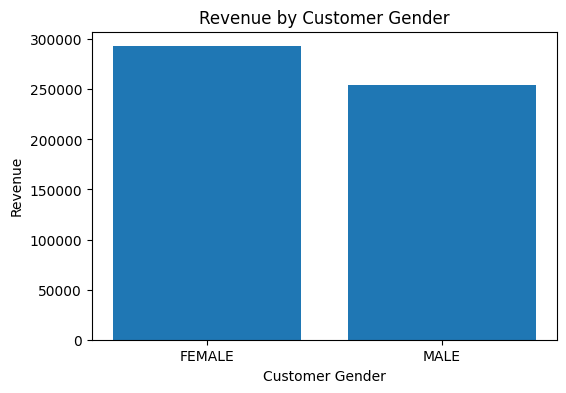

In [54]:
# 📊 4. Nice Plot (Bar Chart)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(df_gender["customer_gender"], df_gender["revenue"])

plt.title("Revenue by Customer Gender")
plt.xlabel("Customer Gender")
plt.ylabel("Revenue")

plt.show()

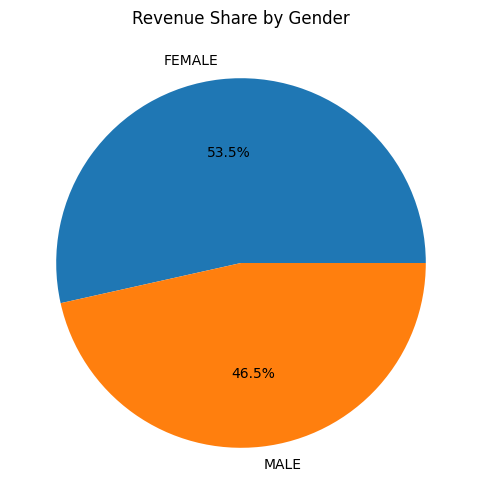

In [55]:
# 🔥 Optional Upgrade (Pie Chart)

plt.figure(figsize=(6,6))
plt.pie(df_gender["revenue"],
        labels=df_gender["customer_gender"],
        autopct='%1.1f%%')

plt.title("Revenue Share by Gender")
plt.show()

# 📈 5. Business Analysis

```
Insights:
	•	compare purchasing behavior
	•	identify dominant segment
	•	support targeted campaigns

⸻

Example interpretation:
	•	balanced split → broad appeal
	•	one segment dominates → opportunity for targeting

⸻

🧠 Key Insight

👉 This is another fact-only query

No joins needed because:

customer_gender is stored in fact_sales


⸻

💡 Teaching Moment (VERY IMPORTANT)

Ask:

“Should customer_gender be a dimension table?”

👉 Answer:
	•	No (for this case):
	•	very low cardinality
	•	no additional attributes
	•	not worth a dimension table

⸻

🔥 OLAP Concept

This is:

Slice (by customer segment)

⸻

⚠️ Important Note (Nice to mention)

👉 In real systems:
	•	gender alone is too simplistic
	•	we use richer dimensions:
	•	age group
	•	income
	•	region

⸻

🚀 Where you are now

You’ve now demonstrated:
	•	product analytics ✔️
	•	ranking ✔️
	•	geography ✔️
	•	time-series ✔️
	•	category ✔️
	•	segmentation ✔️

👉 This is very strong BI coverage

⸻

👉 Next Step: “Cell 17”

Next we do:

📊 BI Query 7 — Publisher Performance

This introduces:
	•	supplier/vendor analysis
	•	join with dimension
	•	business partnerships insight 🔥
```

---
# 📊 CELL 17 — BI Query 7: <br> Revenue by Publisher

```
Now we move into publisher/vendor analytics, 
which is very realistic in business settings. 🔥

⸻

📊 CELL 17 — BI Query 7: Revenue by Publisher

⸻

✅ 1. What are we doing?

We are:
	•	aggregating revenue
	•	grouping by publisher

👉 This requires a join with dim_book

⸻

💼 2. Business Value

This answers:

“Which publishers generate the most revenue?”

⸻

Why this matters:
	•	vendor partnerships 🤝
	•	negotiation leverage 💰
	•	catalog strategy 📚

⸻
```

In [56]:
   
#🧾 3. SQL

query = """
SELECT
    b.publisher,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.publisher
ORDER BY revenue DESC
"""

df_publisher = con.execute(query).df()
df_publisher

,publisher,revenue
0,Prentice Hall,233114.74
1,O'Reilly,158206.67
2,Penguin,156231.57


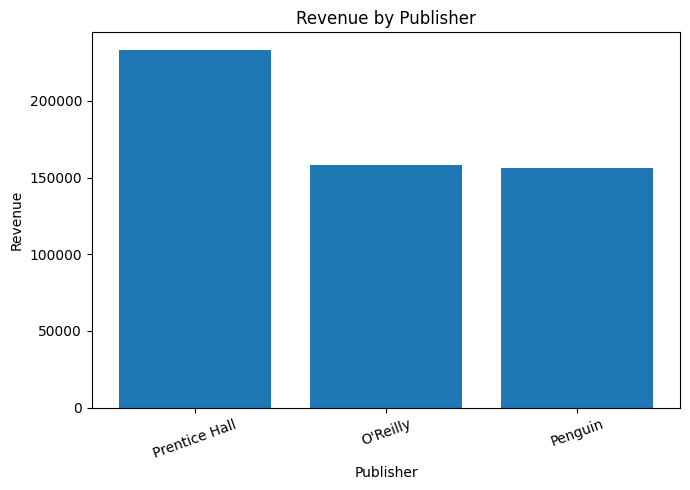

In [57]:
# 📊 4. Nice Plot (Bar Chart)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.bar(df_publisher["publisher"], df_publisher["revenue"])

plt.title("Revenue by Publisher")
plt.xlabel("Publisher")
plt.ylabel("Revenue")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

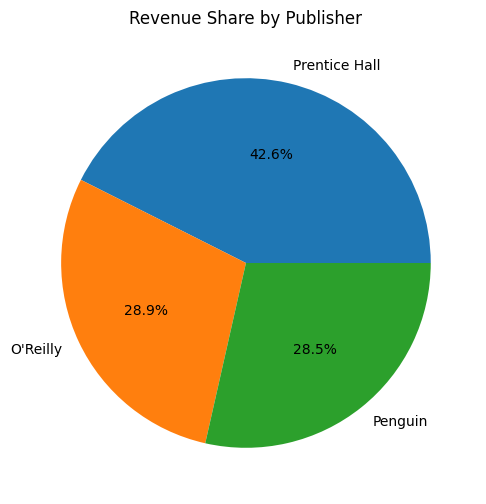

In [58]:
# 🔥 Optional Upgrade (Pie Chart)

plt.figure(figsize=(6,6))
plt.pie(df_publisher["revenue"],
        labels=df_publisher["publisher"],
        autopct='%1.1f%%')

plt.title("Revenue Share by Publisher")
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	identify top-performing publishers
	•	measure vendor contribution
	•	evaluate portfolio balance

⸻

Example interpretation:
	•	Penguin dominates → strong partnership
	•	O’Reilly strong → technical market success
	•	smaller publishers → niche opportunities

⸻

🧠 Key Insight

👉 This query demonstrates:
	•	fact table → measures
	•	dimension table → grouping attribute

⸻

💡 Teaching Moment (VERY STRONG)

Ask:

“Why do we need to JOIN dim_book here?”

👉 Answer:
	•	publisher is NOT in fact table
	•	stored in dimension
	•	avoids duplication

⸻

🔥 OLAP Concept

This is:

Slice (by supplier dimension)

⸻

🧠 Advanced Insight

This type of analysis supports:
	•	supplier optimization
	•	procurement strategy
	•	contract negotiation

⸻

🚀 Where you are now

You’ve now covered:
	•	product ✔️
	•	ranking ✔️
	•	geography ✔️
	•	time ✔️
	•	category ✔️
	•	segmentation ✔️
	•	vendor analysis ✔️

👉 This is a very complete BI pipeline

⸻

👉 Next Step: “Cell 18”

Next we do:

📊 BI Query 8 — Genre × Sale Type (Multi-Dimensional Analysis)

This introduces:
	•	true OLAP cube thinking 🔥
	•	multiple dimensions together
	•	pivot-style analysis
```

---
# 📊 CELL 18 — BI Query 8: <br> Genre × Sale Type (Multi-Dimensional Analysis)

```
This is where we introduce true OLAP thinking 🔥

Multiple dimensions at once = real analytical power.

⸻

📊 CELL 18 — BI Query 8: Genre × Sale Type (Multi-Dimensional Analysis)

⸻

✅ 1. What are we doing?

We are:
	•	aggregating revenue
	•	grouping by two dimensions:

book_genre  ×  sale_type

👉 This is multi-dimensional analysis

⸻

💼 2. Business Value

This answers:

“How do different genres perform across sales channels?”

⸻

Why this matters:
	•	channel strategy (ONLINE vs INSTORE)
	•	genre-specific marketing 🎯
	•	product-channel alignment

⸻
```

In [59]:
#🧾 3. SQL

query = """
SELECT
    b.book_genre,
    f.sale_type,
    ROUND(SUM(f.final_price), 2) AS revenue
FROM fact_sales f
JOIN dim_book b
  ON f.book_id = b.book_id
GROUP BY b.book_genre, f.sale_type
ORDER BY b.book_genre, f.sale_type
"""

df_genre_channel = con.execute(query).df()
df_genre_channel

,book_genre,sale_type,revenue
0,Business,INSTORE,37444.31
1,Business,ONLINE,39215.04
2,Data Science,INSTORE,62440.73
3,Data Science,ONLINE,67646.76
4,Fiction,INSTORE,53586.31
5,Fiction,ONLINE,62804.37
6,History,INSTORE,50851.25
7,History,ONLINE,61191.12
8,Technology,INSTORE,52942.47
9,Technology,ONLINE,59430.62


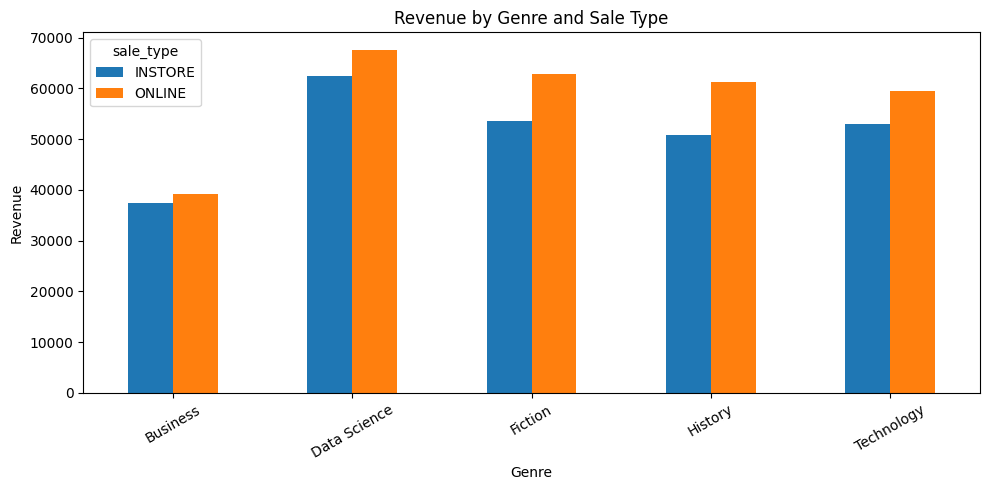

In [60]:
# 📊 4. Nice Plot (Grouped Bar Chart)

import matplotlib.pyplot as plt

# Pivot for better plotting
pivot_df = df_genre_channel.pivot(
    index="book_genre",
    columns="sale_type",
    values="revenue"
)

pivot_df.plot(kind="bar", figsize=(10,5))

plt.title("Revenue by Genre and Sale Type")
plt.xlabel("Genre")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

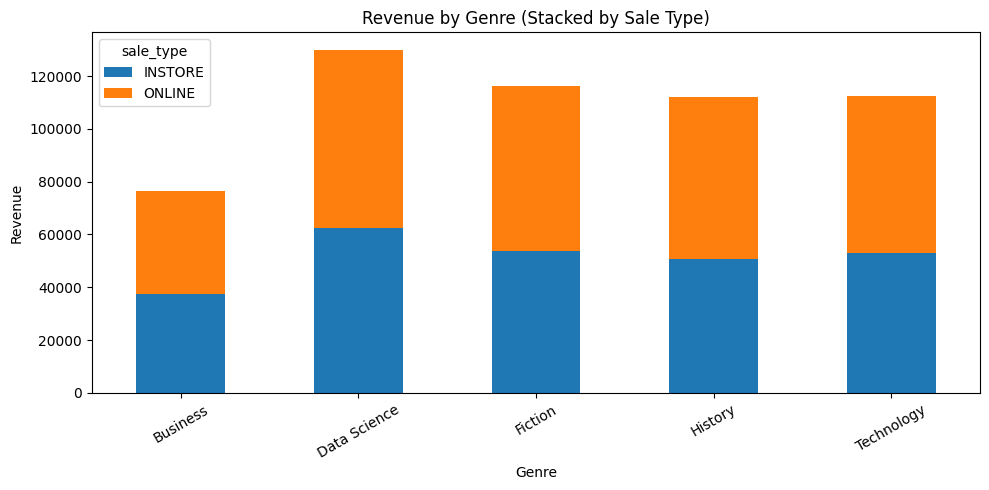

In [61]:
# 🔥 Optional Upgrade (Stacked Bar)

pivot_df.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Revenue by Genre (Stacked by Sale Type)")
plt.xlabel("Genre")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	which genres perform better online
	•	which genres perform better in-store
	•	channel preference by category

⸻

Example interpretation:
	•	Data Science → strong ONLINE
	•	Fiction → strong INSTORE
	•	Business → balanced

⸻

🧠 Key Insight

👉 You are analyzing:

Dimension 1: Genre
Dimension 2: Channel
Measure: Revenue


⸻

💡 Teaching Moment (VERY STRONG)

Ask:

“Why is this more powerful than single-dimension analysis?”

👉 Answer:
	•	reveals relationships between dimensions
	•	uncovers hidden patterns
	•	supports better decisions

⸻

🔥 OLAP Concept

This is:

Cube / Multi-Dimensional Analysis

⸻

🧠 Advanced Insight

This is equivalent to:

GROUP BY (Genre, Sale_Type)

👉 foundation of:
	•	pivot tables
	•	dashboards
	•	BI tools

⸻

🚀 Where you are now

You’ve now demonstrated:
	•	single-dimension analysis ✔️
	•	ranking ✔️
	•	time-series ✔️
	•	segmentation ✔️
	•	multi-dimensional analysis ✔️

👉 This is advanced BI thinking

⸻

👉 Next Step: “Cell 19”

Next we do:

📊 BI Query 9 — Top Country per Genre (Advanced Ranking)

This introduces:
	•	window functions
	•	partitioning
	•	advanced SQL 🔥
```

---
# 📊 CELL 19 — BI Query 9: <br> Top Country per Genre (Advanced Ranking)

```
Now we step into advanced SQL / OLAP — 
this is where students level up. 🔥

⸻

📊 CELL 19 — BI Query 9: Top Country per Genre (Advanced Ranking)

⸻

✅ 1. What are we doing?

We are:
	•	finding the best-performing country for each genre
	•	using:
	•	aggregation
	•	window functions (RANK)

👉 This is partitioned ranking

⸻

💼 2. Business Value

This answers:

“For each genre, which country performs best?”

⸻

Why this matters:
	•	localized marketing 🌍
	•	regional strategy 📊
	•	targeted expansion 🚀

⸻
```

In [62]:
# 🧾 3. SQL

query = """
WITH genre_country AS (
    SELECT
        b.book_genre,
        l.country,
        ROUND(SUM(f.final_price), 2) AS revenue
    FROM fact_sales f
    JOIN dim_book b
      ON f.book_id = b.book_id
    JOIN dim_location l
      ON f.location_id = l.location_id
    GROUP BY b.book_genre, l.country
),

ranked AS (
    SELECT
        *,
        RANK() OVER (
            PARTITION BY book_genre
            ORDER BY revenue DESC
        ) AS rnk
    FROM genre_country
)

SELECT
    book_genre,
    country,
    revenue
FROM ranked
WHERE rnk = 1
ORDER BY revenue DESC
"""

df_top_country_genre = con.execute(query).df()
df_top_country_genre

,book_genre,country,revenue
0,Data Science,USA,33329.38
1,Fiction,USA,29575.36
2,History,USA,28758.99
3,Technology,USA,27317.33
4,Business,USA,19460.99


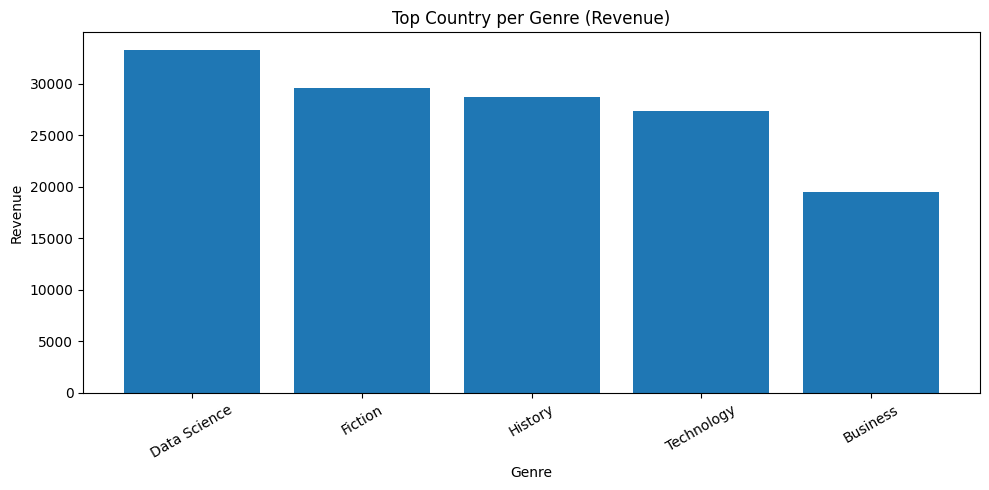

In [63]:
# 📊 4. Nice Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_top_country_genre["book_genre"],
        df_top_country_genre["revenue"])

plt.title("Top Country per Genre (Revenue)")
plt.xlabel("Genre")
plt.ylabel("Revenue")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 📈 5. Business Analysis

```
Insights:
	•	each genre has a strongest market
	•	reveals regional preferences
	•	supports geo-targeted strategy

⸻

Example interpretation:
	•	Data Science → USA dominates
	•	Fiction → UK strongest
	•	History → Germany strong

👉 Different markets behave differently

⸻

🧠 Key Insight

👉 This query combines:
	•	aggregation
	•	grouping
	•	window function (RANK)
	•	filtering

⸻

💡 Teaching Moment (VERY STRONG)

Ask:

“Why can’t we just use GROUP BY and MAX?”

👉 Answer:
	•	GROUP BY gives totals
	•	but NOT which row produced the max

👉 Window functions solve this

⸻

🔥 OLAP Concept

This is:

Top-N per group (partitioned ranking)

⸻

🧠 Advanced Insight

This pattern is used in:
	•	recommendation systems
	•	segmentation
	•	performance analysis

⸻

🚀 Where you are now

You’ve demonstrated:
	•	basic aggregation ✔️
	•	joins ✔️
	•	time-series ✔️
	•	multi-dimensional ✔️
	•	advanced SQL ✔️

⸻

👉 Final Step: “Cell 20”

We’ll finish with:

📊 BI Query 10 — Executive Summary KPI Dashboard

This ties everything together into:
	•	a dashboard-style output
	•	real business reporting 🔥
```

---
# 📊 CELL 20 — BI Query 10: <br> Executive KPI Dashboard

```
Perfect — this is the final cell and the most business-facing one. 🔥

This is where everything becomes an executive dashboard.

⸻

📊 CELL 20 — BI Query 10: Executive KPI Dashboard

⸻

✅ 1. What are we doing?

We are:
	•	computing key business KPIs
	•	summarizing the entire business in one query

👉 This is a dashboard-style aggregation

⸻

💼 2. Business Value

This answers:

“How is the business performing overall?”

⸻

KPIs included:
	•	total revenue 💰
	•	total transactions 📦
	•	average order value 📊
	•	total discount given 🎯

⸻
```

In [64]:
# 🧾 3. SQL

query = """
SELECT
    COUNT(*) AS total_transactions,
    ROUND(SUM(final_price), 2) AS total_revenue,
    ROUND(AVG(final_price), 2) AS avg_order_value,
    ROUND(SUM(discount), 2) AS total_discount
FROM fact_sales
"""

df_kpi = con.execute(query).df()
df_kpi

,total_transactions,total_revenue,avg_order_value,total_discount
0,20000,547552.98,27.38,50105.65


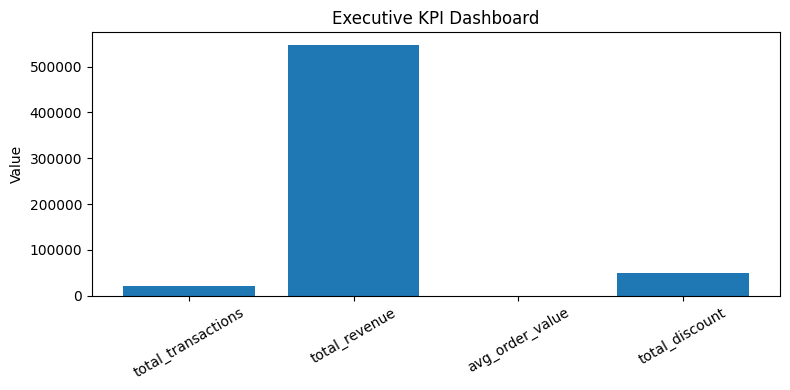

In [65]:
# 📊 4. Nice Plot (KPI Visualization)

import matplotlib.pyplot as plt

# Convert to long format for plotting
df_plot = df_kpi.melt(var_name="metric", value_name="value")

plt.figure(figsize=(8,4))
plt.bar(df_plot["metric"], df_plot["value"])

plt.title("Executive KPI Dashboard")
plt.ylabel("Value")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [66]:
# 🔥 Optional Upgrade (Cleaner Dashboard Style)

for col in df_kpi.columns:
    print(f"{col}: {df_kpi[col][0]:,.2f}")

total_transactions: 20,000.00
total_revenue: 547,552.98
avg_order_value: 27.38
total_discount: 50,105.65


---
## 📈 5. Business Analysis

#### Insights:
```
	•	total revenue → overall performance
	•	avg order value → pricing effectiveness
	•	total discount → promotion impact
```
    
⸻

#### Example interpretation:
```
	•	high revenue + low discount → strong pricing
	•	high discount → aggressive promotions
	•	low avg order → upsell opportunity
```
    
⸻

#### 🧠 Key Insight

```
👉 This query uses:
	•	pure fact table
	•	no joins needed
	•	maximum efficiency
```
⸻

#### 💡 Teaching Moment (VERY STRONG)

```
Ask:

“Why don’t we join dimension tables here?”

👉 Answer:
	•	KPIs don’t need grouping
	•	fact table already has measures
	•	joins would add unnecessary cost
```
⸻

#### 🔥 OLAP Concept

```
This is:

Aggregation / KPI Reporting
```
⸻
    

#### 🎯 FINAL RESULT — What You Built

```
You now have:

🟫 Bronze
	•	raw messy data

⚪ Silver
	•	cleaned, validated data

🟡 Gold (Star Schema)
	•	fact_sales
	•	dim_book
	•	dim_location
	•	dim_date

📊 BI Layer
	•	10 analytical queries
	•	full OLAP coverage
```
⸻

#### 🧠 Big Picture (Very Important)

```
You just demonstrated:

Raw Data → Clean Data → Star Schema → Business Insights
```

⸻

#### 💡 Final Teaching Moment

```
Ask students:

“Why didn’t we run BI queries directly on CSV files?”

👉 Answer:
	•	messy data ❌
	•	no structure ❌
	•	slow ❌

👉 Data warehouse enables:
	•	speed ⚡
	•	consistency ✅
	•	scalability 🚀
```
⸻

#### 🚀 You’re Done

This is a complete DW pipeline + BI system 👏
    